# Tale of Two Sonnets: On LLM Token Burn, Effort, and Compression


<a href="https://www.kaggle.com/code/addarm/tale_of_two_sonnets" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


![The Sonnets - OpenAI 2026](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/tale_of_two_sonnets_banner.png)

This is a short follow-up to [the caveman critique piece](https://medium.com/hecatus-research/less-is-more-for-llms-a-critique-of-prompt-based-compression-910978d8bad4), written after Anthropic released Claude Sonnet 5.

That piece tested prompt-based output compression on a local proxy model, because the actual target of the claims, frontier RLHF models, wasn't available to test directly. 

Here we hit real Claude models and look at what changed under the hood between Sonnet 4.6 and Sonnet 5: how each one's reasoning control param burns tokens, and whether that param even works the same way across versions.

## Setup

For this article I used boto3 and Bedrock.

In [2]:
%matplotlib inline
import json
import re
import time
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from scipy import stats
from tqdm.auto import tqdm

load_dotenv()
np.random.seed(42)

REGION = "eu-west-1"
MODEL_46 = "global.anthropic.claude-sonnet-4-6"
MODEL_5 = "global.anthropic.claude-sonnet-5"

client = boto3.client("bedrock-runtime", region_name=REGION)

In [3]:
print(f"Region: {REGION}")
print(f"Sonnet 4.6 model id: {MODEL_46}")
print(f"Sonnet 5 model id:   {MODEL_5}")

Region: eu-west-1
Sonnet 4.6 model id: global.anthropic.claude-sonnet-4-6
Sonnet 5 model id:   global.anthropic.claude-sonnet-5


## LLM Reproducibility and caching

Claude has no public seed parameter, unlike some other providers. Temperature is the only lever we get, and it's a weaker one on Sonnet 5 than on Sonnet 4.6. Sonnet 4.6 forces temperature to 1.0 whenever thinking is switched on, but accepts any value, including 0, once thinking is off. Sonnet 5 rejects `temperature=0` even on its default, no-thinking-field call path, its `temperature` param is deprecated.

Adaptive reasoning runs unconditionally on Sonnet 5, whether or not you ask for it, and the model won't let you sample colder than that.

So we set temperature to 0 on Sonnet 4.6 calls that aren't thinking-locked to 1.0, and leave Sonnet 5 alone. We add repeated trials  to turn a noisy sample generations, into a distribution.

Sonnet 5 isn't a clean drop-in for a token-counting experiment like this one. Three things changed at once between the two models: the tokenizer (Anthropic states Sonnet 5's tokenizer produces roughly 30% more tokens than Sonnet 4.6's for the same text), the reasoning defaults (adaptive thinking runs by default on Bedrock, off only if you explicitly disable it), and the accepted sampling controls (Sonnet 5 rejects `temperature=0`, as above). 

Every experiment below caches its raw results the first time it runs live, to prevent unnecessary token burn.

In [4]:
CACHE_DIR = Path("cache_tale_of_two_sonnets")
CACHE_DIR.mkdir(exist_ok=True)
FORCE_RERUN = False


def cached_run(cache_name, run_fn):
    path = CACHE_DIR / f"{cache_name}.json"
    if path.exists() and not FORCE_RERUN:
        with open(path) as f:
            return pd.DataFrame(json.load(f))
    df = run_fn()
    with open(path, "w") as f:
        json.dump(df.to_dict(orient="records"), f, indent=1)
    return df

## Token Burn and Reasoning Params

The API itself changed between these two models, and that's worth reporting before any number. 

Sonnet 4.6 still accepts the older extended-thinking schema, `thinking: {type: enabled, budget_tokens: N}`, a hard token ceiling you hand the model, and it forces `temperature` to 1.0 whenever thinking is switched on. Sonnet 5 rejects that schema outright. 

Anthropic moved from a token-budget parameter to a qualitative-effort param between these two model generations. The sweep below shows the two parameters behave differently.

We test five small, checkable questions (the same ones from the caveman piece) under three reasoning configs per model. 

For Sonnet 4.6: thinking off, `budget_tokens=1024`, and `budget_tokens=8192`. For Sonnet 5: `effort=low`, `effort=medium`, and `effort=high`.

In [5]:
benchmark = [
    ("What is 17 * 23?", "391"),
    ("In Python, what does len([1,2,3]) return?", "3"),
    ("What HTTP status code means 'Not Found'?", "404"),
    ("What is the time complexity of binary search?", "log"),
    ("Name the HTTP method used to update a resource.", "PUT"),
]


def converse(model_id, question, system=None, extra_fields=None, temperature=None):
    kwargs = {"modelId": model_id, "messages": [{"role": "user", "content": [{"text": question}]}]}
    if system:
        kwargs["system"] = [{"text": system}]
    if extra_fields:
        kwargs["additionalModelRequestFields"] = extra_fields
    if temperature is not None:
        kwargs["inferenceConfig"] = {"temperature": temperature}
    t0 = time.time()
    resp = client.converse(**kwargs)
    latency = time.time() - t0
    usage = resp["usage"]
    text = "".join(c.get("text", "") for c in resp["output"]["message"]["content"])
    visible_chars = len(text)
    return {
        "input_tokens": usage["inputTokens"],
        "output_tokens": usage["outputTokens"],
        "total_tokens": usage["totalTokens"],
        "latency": round(latency, 2),
        "text": text,
        "visible_chars": visible_chars,
        "visible_words": len(text.split()),
        "visible_sentences": max(1, len(re.findall(r"[.!?]+", text))) if text else 0,
        "output_tokens_per_char": round(usage["outputTokens"] / visible_chars, 3) if visible_chars else np.nan,
    }

In [6]:
configs_46 = [
    ("off", None),
    ("budget_1024", {"thinking": {"type": "enabled", "budget_tokens": 1024}}),
    ("budget_8192", {"thinking": {"type": "enabled", "budget_tokens": 8192}}),
]
configs_5 = [
    ("effort_low", {"thinking": {"type": "adaptive"}, "output_config": {"effort": "low"}}),
    ("effort_medium", {"thinking": {"type": "adaptive"}, "output_config": {"effort": "medium"}}),
    ("effort_high", {"thinking": {"type": "adaptive"}, "output_config": {"effort": "high"}}),
]


def run_section1_sweep():
    rows_a = []
    for question, expected in tqdm(benchmark):
        for label, extra in configs_46:
            r = converse(MODEL_46, question, extra_fields=extra, temperature=1.0 if extra else 0)
            rows_a.append({"model": "sonnet-4.6", "config": label, "question": question, "expected": expected, **r})
        for label, extra in configs_5:
            r = converse(MODEL_5, question, extra_fields=extra, temperature=1.0)
            rows_a.append({"model": "sonnet-5", "config": label, "question": question, "expected": expected, **r})
    return pd.DataFrame(rows_a)


df_a = cached_run("section1_sweep", run_section1_sweep)

In [7]:
summary_a = (
    df_a.groupby(["model", "config"])
    .agg(
        mean_input=("input_tokens", "mean"),
        mean_output=("output_tokens", "mean"),
        mean_total=("total_tokens", "mean"),
        mean_latency=("latency", "mean"),
    )
    .round(1)
)
print(summary_a.to_string())

                          mean_input  mean_output  mean_total  mean_latency
model      config                                                          
sonnet-4.6 budget_1024          46.8        239.2       286.0           5.6
           budget_8192          46.8        255.2       302.0           5.2
           off                  17.8        209.8       227.6           4.5
sonnet-5   effort_high          19.8        265.4       285.2           5.1
           effort_low           19.8        176.0       195.8           4.5
           effort_medium        19.8        266.8       286.6           5.4


One pattern holds up clearly. Sonnet 5's `effort_low` is reliably the cheapest and fastest of its three levels. `effort_medium` and `effort_high` then get close to each other in token burn, more like a plateau than a smooth three-step ramp: the real jump happens once, between low and medium, not twice. 

Latency doesn't track token burn as cleanly, though. In this run `effort_medium` is slightly slower than `effort_high` despite burning about the same tokens, so treat "effort raises latency" as a loose trend rather than a strict ordering across levels.

Sonnet 4.6's `budget_tokens` behaves less predictably still. In this run, `budget_8192` burns more than `budget_1024`. In other runs of the same sweep the two have converged, or flipped. A numeric token ceiling doesn't produce the same reliable response that Sonnet 5's effort levels do.

Sonnet 4.6 with thinking `off` still burns a fair number of output tokens on its own. The base model likes to show its arithmetic even without an explicit reasoning mode. Most of that token cost comes from the model's baseline verbosity, the same effect the original caveman piece was built around.

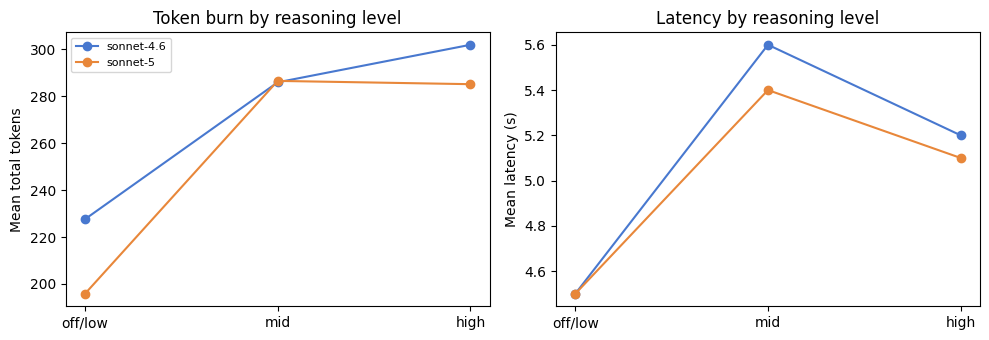

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

order = {"sonnet-4.6": ["off", "budget_1024", "budget_8192"], "sonnet-5": ["effort_low", "effort_medium", "effort_high"]}
labels = ["off/low", "mid", "high"]
colors = {"sonnet-4.6": "#4878cf", "sonnet-5": "#e8873a"}

for model, color in colors.items():
    sub = summary_a.loc[model].reindex(order[model])
    axes[0].plot(range(len(sub)), sub["mean_total"], marker="o", label=model, color=color)
    axes[1].plot(range(len(sub)), sub["mean_latency"], marker="o", label=model, color=color)

for ax, title, ylabel in [
    (axes[0], "Token burn by reasoning level", "Mean total tokens"),
    (axes[1], "Latency by reasoning level", "Mean latency (s)"),
]:
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Noisy Results?

Five questions is a thin base for calling something "noisy" versus "reliable". 

Both models are stochastic even at their most controlled settings, so we fix one question and repeat it 30 times per config, then compare total tokens with an effect size and two significance checks (Welch's t-test and Mann-Whitney U, since a plain t-test alone can mislead when one group's variance is near zero). 

In [9]:
N_TRIALS = 30
fixed_question, fixed_expected = benchmark[0]


def run_section1_significance():
    rows = []
    for _ in tqdm(range(N_TRIALS)):
        r = converse(MODEL_46, fixed_question, extra_fields=configs_46[1][1], temperature=1.0)
        rows.append({"model": "sonnet-4.6", "config": "budget_1024", **r})
        r = converse(MODEL_46, fixed_question, extra_fields=configs_46[2][1], temperature=1.0)
        rows.append({"model": "sonnet-4.6", "config": "budget_8192", **r})
        r = converse(MODEL_5, fixed_question, extra_fields=configs_5[0][1], temperature=1.0)
        rows.append({"model": "sonnet-5", "config": "effort_low", **r})
        r = converse(MODEL_5, fixed_question, extra_fields=configs_5[1][1], temperature=1.0)
        rows.append({"model": "sonnet-5", "config": "effort_medium", **r})
    return pd.DataFrame(rows)


df_sig1 = cached_run("section1_significance", run_section1_significance)

In [10]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)


def get_total_tokens(model, config):
    mask = (df_sig1["model"] == model) & (df_sig1["config"] == config)

    return df_sig1.loc[mask, "total_tokens"].values


def cohens_d(sample_a, sample_b):
    n_a = len(sample_a)
    n_b = len(sample_b)

    var_a = sample_a.std(ddof=1) ** 2
    var_b = sample_b.std(ddof=1) ** 2

    pooled_variance = ((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2)

    pooled_sd = np.sqrt(pooled_variance)

    if pooled_sd == 0:
        return np.nan

    return (sample_a.mean() - sample_b.mean()) / pooled_sd


def compare_samples(sample_a, sample_b, label):
    d = cohens_d(sample_a, sample_b)

    t_stat, p_welch = stats.ttest_ind(
        sample_a,
        sample_b,
        equal_var=False,
    )

    u_stat, p_mwu = stats.mannwhitneyu(
        sample_a,
        sample_b,
        alternative="two-sided",
    )

    return {
        "comparison": label,
        "n_a": len(sample_a),
        "mean_a": sample_a.mean(),
        "sd_a": sample_a.std(ddof=1),
        "n_b": len(sample_b),
        "mean_b": sample_b.mean(),
        "sd_b": sample_b.std(ddof=1),
        "cohens_d": d,
        "welch_t": t_stat,
        "welch_p": p_welch,
        "mwu_u": u_stat,
        "mwu_p": p_mwu,
    }


sonnet_46_budget_1024 = get_total_tokens("sonnet-4.6", "budget_1024")
sonnet_46_budget_8192 = get_total_tokens("sonnet-4.6", "budget_8192")

sonnet_5_effort_low = get_total_tokens("sonnet-5", "effort_low")
sonnet_5_effort_medium = get_total_tokens("sonnet-5", "effort_medium")


results = pd.DataFrame(
    [
        compare_samples(
            sonnet_46_budget_1024,
            sonnet_46_budget_8192,
            "Sonnet 4.6: budget_1024 vs budget_8192",
        ),
        compare_samples(
            sonnet_5_effort_low,
            sonnet_5_effort_medium,
            "Sonnet 5: effort_low vs effort_medium",
        ),
    ]
)

results = results.round(
    {
        "mean_a": 1,
        "sd_a": 1,
        "mean_b": 1,
        "sd_b": 1,
        "cohens_d": 2,
        "welch_t": 2,
        "welch_p": 3,
        "mwu_u": 1,
        "mwu_p": 3,
    }
)

print(results.to_string(index=False))

                            comparison  n_a  mean_a  sd_a  n_b  mean_b  sd_b  cohens_d  welch_t  welch_p  mwu_u  mwu_p
Sonnet 4.6: budget_1024 vs budget_8192   30   141.2   4.4   30   142.0   0.0     -0.27    -1.04    0.306  420.0  0.161
 Sonnet 5: effort_low vs effort_medium   30    77.9   6.6   30    79.1   5.7     -0.20    -0.77    0.442  430.0  0.771


Neither difference is convincing on this question, and the numbers get less convincing the closer you look. 

Sonnet 4.6's `budget_1024` versus `budget_8192` comes back at Cohen's d = -0.27, Welch p = 0.31. Sonnet 5's `effort_low` versus `effort_medium` comes back at d = -0.20, p = 0.44. Thirty repeats each, same arithmetic question, different configs, and both effects are small enough to call noise.

The `budget_8192` group is also close to constant (sd = 0.0 tokens across 30 runs), which means the t-test's own variance assumption barely holds for that comparison. The effect size and the raw means are more honest here than the p-value: a bigger ceiling makes Sonnet 4.6 answers converge on the same short response almost every time.

Averaged across five questions of different difficulty, effort and budget looked flat. Pinned to one easy question and repeated enough times to check, neither params move the needle with any confidence. 

## Does caveman still compress on Sonnet 5?

Now the question we were preparing for, does Caveman still Cavemen? 

The caveman piece found that a compressed system prompt cuts output tokens sharply on frontier-style models, with no accuracy loss on a small benchmark. The closest formal treatment of this is CAVEWOMAN, which studies caveman-style compression on both sides of a request: input and output. It finds output compression cuts realized cost on most models tested, while input compression is closer to a lose-lose, since models compensate with longer replies even as accuracy drops. Our question here is narrower still: whether output compression, specifically, still behaves the same way after Sonnet 5's tokenizer and adaptive-thinking changes on Bedrock.

We check whether it holds across the version change, running baseline and caveman system prompts on both models, no thinking config override, same five questions.

In [11]:
SYSTEM_BASELINE = "You are a helpful assistant."
SYSTEM_CAVEMAN = (
    "Reply in compressed caveman speak. Rules:\n"
    "- Drop articles (a, an, the)\n"
    "- Use sentence fragments, not full sentences\n"
    "- No filler, no pleasantries, no hedging\n"
    "- Keep code blocks unchanged\n\n"
    "Example:\n"
    "User: What does a Python decorator do?\n"
    "Assistant: Wraps function. Adds behavior before/after call without modifying original. "
    "User: How does git rebase work?\n"
    "Assistant: Replays commits onto different base. Rewrites history. "
)


def run_section2_sweep():
    rows_b = []
    for question, expected in tqdm(benchmark):
        for style_label, system in [("baseline", SYSTEM_BASELINE), ("caveman", SYSTEM_CAVEMAN)]:
            for model_id, model_label in [(MODEL_46, "sonnet-4.6"), (MODEL_5, "sonnet-5")]:
                temp = 0 if model_id == MODEL_46 else None
                r = converse(model_id, question, system=system, temperature=temp)
                r["expected_string_match"] = expected.lower() in r["text"].lower()
                rows_b.append({"model": model_label, "style": style_label, "question": question, **r})
    return pd.DataFrame(rows_b)


df_b = cached_run("section2_sweep", run_section2_sweep)

In [12]:
rows = []
for model in ["sonnet-4.6", "sonnet-5"]:
    base = df_b[(df_b["model"] == model) & (df_b["style"] == "baseline")]["output_tokens"].mean()
    cave = df_b[(df_b["model"] == model) & (df_b["style"] == "caveman")]["output_tokens"].mean()
    match_base = df_b[(df_b["model"] == model) & (df_b["style"] == "baseline")]["expected_string_match"].mean()
    match_cave = df_b[(df_b["model"] == model) & (df_b["style"] == "caveman")]["expected_string_match"].mean()
    rows.append(
        {
            "model": model,
            "baseline_mean_out": round(base, 1),
            "caveman_mean_out": round(cave, 1),
            "compression": f"{1 - cave / base:.1%}",
            "baseline_expected_string_match": match_base,
            "caveman_expected_string_match": match_cave,
        }
    )

print(pd.DataFrame(rows).to_string(index=False))

     model  baseline_mean_out  caveman_mean_out compression  baseline_expected_string_match  caveman_expected_string_match
sonnet-4.6              175.6              10.0       94.3%                             1.0                            1.0
  sonnet-5              217.2              18.6       91.4%                             1.0                            1.0


Bedrock's `outputTokens` is a billing metric as much as a verbosity metric: it bundles any thinking tokens Sonnet 5 spends in the background, and Sonnet 5's tokenizer produces roughly 30% more tokens than Sonnet 4.6's for the same text (see the reproducibility note above). A token-count comparison between the two models is comparing tokens with different meters attached. If you use a different harness, you'll have different metrics available.

The table below adds tokenizer-neutral, thinking-neutral measures of the same responses: visible character count, word count, sentence count, and `outputTokens` per visible character. These describe what the model actually wrote, independent of which tokenizer counted it or how much invisible thinking happened first.

In [13]:
metric_rows = []
for model in ["sonnet-4.6", "sonnet-5"]:
    for style in ["baseline", "caveman"]:
        sub = df_b[(df_b["model"] == model) & (df_b["style"] == style)]
        metric_rows.append(
            {
                "model": model,
                "style": style,
                "visible_words": round(sub["visible_words"].mean(), 1),
                "visible_chars": round(sub["visible_chars"].mean(), 1),
                "visible_sentences": round(sub["visible_sentences"].mean(), 1),
                "output_tokens": round(sub["output_tokens"].mean(), 1),
                "output_tokens_per_char": round(sub["output_tokens_per_char"].mean(), 3),
                "latency": round(sub["latency"].mean(), 2),
            }
        )

print(pd.DataFrame(metric_rows).to_string(index=False))

     model    style  visible_words  visible_chars  visible_sentences  output_tokens  output_tokens_per_char  latency
sonnet-4.6 baseline           90.4          536.4                4.2          175.6                   0.364     3.85
sonnet-4.6  caveman            4.0           22.4                1.6           10.0                   1.805     1.38
  sonnet-5 baseline           98.4          537.6                3.6          217.2                   0.438     4.70
  sonnet-5  caveman            7.4           39.2                1.8           18.6                   0.661     2.22


Reading the token compression ratio alone and the two models look close: 94.3% for Sonnet 4.6, 91.4% for Sonnet 5. 

Read the visible characters and the gap is bigger in relative terms: Sonnet 4.6's caveman replies average 22.4 characters, Sonnet 5's average 39.2.

Both numbers can be true at once because they're not measuring the same thing. `outputTokens` on Sonnet 5 bundles the tokenizer's own ~30% inflation and whatever background thinking ran before the reply, so it's not a clean stand-in for how much text came out. 

Visible characters skip both effects and count only what showed up in the response. Sonnet 5 is writing meaningfully more caveman-style text than Sonnet 4.6 for the same instruction, just not as dramatically more as the raw token gap in the fixed-question test below will suggest. Expected-string match holds at the same rate under both prompt styles here, but that's a five-question substring check, not a correctness grade. See the manual grading below for where substring matching alone can mislead.

### Is Sonnet 5 too Much for Caveman?

Same logic as before. 

Five questions isn't enough to call one 91% and one 95% meaningfully different, so we fix a question and run 30 trials per model per prompt style at temperature 0, then compare the caveman output-token counts against each other, and against each model's own baseline, using effect size plus Welch's t-test and Mann-Whitney U.

In [14]:
def run_section2_significance():
    rows = []
    for _ in tqdm(range(N_TRIALS)):
        for style_label, system in [("baseline", SYSTEM_BASELINE), ("caveman", SYSTEM_CAVEMAN)]:
            for model_id, model_label in [(MODEL_46, "sonnet-4.6"), (MODEL_5, "sonnet-5")]:
                temp = 0 if model_id == MODEL_46 else None
                r = converse(model_id, fixed_question, system=system, temperature=temp)
                rows.append({"model": model_label, "style": style_label, **r})
    return pd.DataFrame(rows)


df_sig2 = cached_run("section2_significance", run_section2_significance)

In [16]:
def get_output_tokens(model, style):
    mask = (df_sig2["model"] == model) & (df_sig2["style"] == style)

    return df_sig2.loc[mask, "output_tokens"].values


def compare_output_tokens(sample_a, sample_b, label):
    d = cohens_d(sample_a, sample_b)

    t_stat, p_welch = stats.ttest_ind(
        sample_a,
        sample_b,
        equal_var=False,
    )

    u_stat, p_mwu = stats.mannwhitneyu(
        sample_a,
        sample_b,
        alternative="two-sided",
    )

    return {
        "comparison": label,
        "n_a": len(sample_a),
        "mean_a": sample_a.mean(),
        "sd_a": sample_a.std(ddof=1),
        "n_b": len(sample_b),
        "mean_b": sample_b.mean(),
        "sd_b": sample_b.std(ddof=1),
        "cohens_d": d,
        "welch_t": t_stat,
        "welch_p": p_welch,
        "mwu_u": u_stat,
        "mwu_p": p_mwu,
    }


sonnet_46_baseline = get_output_tokens("sonnet-4.6", "baseline")
sonnet_46_caveman = get_output_tokens("sonnet-4.6", "caveman")

sonnet_5_baseline = get_output_tokens("sonnet-5", "baseline")
sonnet_5_caveman = get_output_tokens("sonnet-5", "caveman")


output_results = pd.DataFrame(
    [
        compare_output_tokens(
            sonnet_46_baseline,
            sonnet_46_caveman,
            "Sonnet 4.6: baseline vs caveman",
        ),
        compare_output_tokens(
            sonnet_5_baseline,
            sonnet_5_caveman,
            "Sonnet 5: baseline vs caveman",
        ),
        compare_output_tokens(
            sonnet_46_caveman,
            sonnet_5_caveman,
            "Caveman only: Sonnet 4.6 vs Sonnet 5",
        ),
    ]
)

output_results = output_results.round(
    {
        "mean_a": 1,
        "sd_a": 1,
        "mean_b": 1,
        "sd_b": 1,
        "cohens_d": 2,
        "welch_t": 2,
        "welch_p": 3,
        "mwu_u": 1,
        "mwu_p": 3,
    }
)

print(output_results.to_string(index=False))


                          comparison  n_a  mean_a  sd_a  n_b  mean_b  sd_b  cohens_d  welch_t  welch_p  mwu_u  mwu_p
     Sonnet 4.6: baseline vs caveman   30    56.9   0.3   30     5.0   0.0    289.49  1121.17      0.0  900.0    0.0
       Sonnet 5: baseline vs caveman   30    68.3  18.0   30    38.5  14.8      1.81     7.02      0.0  798.5    0.0
Caveman only: Sonnet 4.6 vs Sonnet 5   30     5.0   0.0   30    38.5  14.8     -3.19   -12.36      0.0    0.0    0.0


This one statistically holds up, and reading the actual replies explains why. 

On this fixed question, Sonnet 4.6's caveman answer is the literal string `391` in all 30 trials, nothing else, every time (visible chars: mean 3.0, sd 0.0). 

But, Sonnet 5's caveman answer starts with the same `17 * 23 = 391.` but keeps going, often with a line like "Small math. Brain do quick, no tool need." or a worked-out `17*20 + 17*3` breakdown (visible chars: mean 36.7, sd 23.8). It's visible text, counted straight off the reply, with no tokenizer or thinking-token accounting involved: Sonnet 5 is writing more of it under the exact same caveman instruction.

Sonnet 4.6 goes from a mean of 56.9 output tokens at baseline to 5.0 under caveman (d = 289, effectively every trial identical at both ends, so the t-test's variance assumption barely holds here and the huge effect size is doing the honest work). Sonnet 5 goes from 68.3 to 38.5 (d = 1.81, Welch p < 0.001, a real and unremarkable-variance effect). And the cross-model comparison, caveman output on Sonnet 4.6 against caveman output on Sonnet 5, comes back at d = -3.19, Welch p < 0.001: Sonnet 5 writes more caveman-style text than Sonnet 4.6 does, on this question, by a wide and text-confirmed margin.

# Conclusion

Compression is the finding that survived the same scrutiny in the experiments. 

Under Bedrock's usage (you'll have your own in your select platform), Sonnet 5 shows weaker token compression from the caveman prompt than Sonnet 4.6 does, but that gap mixes a real ~30% tokenizer inflation and hidden thinking tokens with real verbosity, and the two aren't easy to pull apart from `outputTokens` alone with Boto3. 

Looking at visible characters instead, averaged across five questions, the two models compress to within 3 percentage points of each other on the token metric, but Sonnet 5's caveman replies still run about 1.75x longer in visible text. Pinned to one fixed question and checked against the actual replies, the pattern is stark: Sonnet 4.6 answers `391` and stops, every time; Sonnet 5 answers `391` and then explains itself, in caveman style, most of the time. 

Therefore, a style instruction alone reins in Sonnet 5 less than it reins in Sonnet 4.6 - maybe with more intellegence comes more 'self-respect'?

Thanks for the read!

## References

1. Adeyemi, M. D., Rossi, R. A., & Dernoncourt, F. (2026). *CAVEWOMAN: How Large Language Models Behave Under Linguistic Input and Output Compression*. [arXiv:2606.24083](https://arxiv.org/abs/2606.24083)
2. Anthropic (2026). *What's new in Claude Sonnet 5*. [Claude Platform Docs](https://platform.claude.com/docs/en/about-claude/models/whats-new-sonnet-5)
3. Amazon Web Services (2026). *Claude Sonnet 5 model card*. [AWS Bedrock documentation](https://docs.aws.amazon.com/bedrock/latest/userguide/model-card-anthropic-claude-sonnet-5.html)
4. Amazon Web Services (2026). *Adaptive thinking*. [AWS Bedrock documentation](https://docs.aws.amazon.com/bedrock/latest/userguide/claude-messages-adaptive-thinking.html)
5. Companion piece: [Less is More for LLMs? A Critique of Prompt-Based Compression](https://medium.com/hecatus-research/less-is-more-for-llms-a-critique-of-prompt-based-compression-910978d8bad4)

## Github

Article is available on [Github](https://github.com/adamd1985/quant_research/blob/main/tale_of_two_sonnets.ipynb)

## Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

## CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.